# Problem komiwojażera - Karol Klimek

### Wczytanie bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

### Definicja zmiennych globalnych

In [2]:
liczba_miast = 30
liczebnosc_populacji = 100
bok_siatki = 300

### Losowanie współrzędnych punktów na siatce 300x300

In [3]:
def losowanie_wspolrzednych(siatka=bok_siatki, n_miasta=liczba_miast):
    np.random.seed(42)
    x = np.random.randint(0,siatka,n_miasta)
    y = np.random.randint(0,siatka,n_miasta)
    coords = pd.DataFrame(data={'x':x, 'y':y})
    return coords

coords = losowanie_wspolrzednych()
coords



,x,y
0,102,54
1,270,243
2,106,130
3,71,134
4,188,20
5,20,166
6,102,273
7,121,88
8,214,13
9,87,241


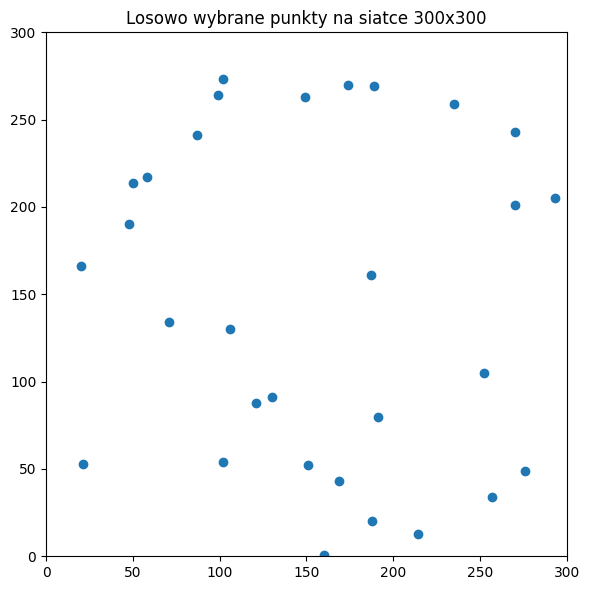

In [4]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(coords['x'], coords['y'])
ax.set_ylim(0,300)
ax.set_xlim(0,300)
ax.set_title(f'Losowo wybrane punkty na siatce {bok_siatki}x{bok_siatki}')
#ax.grid()

plt.tight_layout()
plt.show()

### Generowanie populacji

In [5]:
def generowanie_populacji_poczatkowej(coords=coords, n_pop=liczebnosc_populacji, n_miasta=liczba_miast):
    chromosom = coords.index.values
    populacja = pd.DataFrame(index=range(n_pop), columns=range(n_miasta))

    for i in range(n_pop):
        np.random.shuffle(chromosom)
        populacja.iloc[i,:] = chromosom

    return populacja

populacja = generowanie_populacji_poczatkowej()
populacja

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,3,1,4,5,9,18,13,11,2,10,...,28,26,14,17,12,15,20,7,24,27
1,20,5,0,24,10,28,14,6,29,21,...,19,3,1,16,11,7,27,2,15,13
2,17,25,6,22,20,15,19,29,5,28,...,10,24,9,12,14,4,26,2,21,7
3,10,25,7,22,18,13,28,8,3,23,...,26,14,17,19,9,0,11,21,16,2
4,24,29,8,23,4,3,22,27,5,19,...,17,18,2,7,25,28,20,1,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3,18,17,11,2,14,26,16,21,19,...,20,22,13,8,10,4,7,24,12,27
96,13,3,1,29,24,21,4,18,9,6,...,0,25,5,11,23,14,19,20,26,16
97,16,6,1,18,5,12,23,24,19,9,...,26,29,0,21,28,22,11,25,8,7
98,21,18,0,2,28,24,6,26,29,14,...,27,5,4,19,23,15,3,7,12,13


### Ocena wszystkich osobników populacji początkowej


In [6]:
def fun_dystans(x1,y1, x2, y2):
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)

def fun_jakosci(coords = coords, pop=populacja, n_pop=liczebnosc_populacji, n_miasta = liczba_miast):
    wyniki = []
    coords_np = coords[['x','y']].values

    for i in range(n_pop):
        dystans = 0
        trasa = populacja.iloc[i,:].values
        
        for k in range(n_miasta):
            locus1 = trasa[k]
            locus2 = trasa[(k+1) % n_miasta] #jak dojdzie do ostatniego to wynik modulo bedzie rowny 0, wiec wezmie pierwsza wartosc 

            x1,y1 = coords_np[locus1]
            x2,y2 = coords_np[locus2]
            dystans += round(fun_dystans(x1,y1,x2,y2), 2)
        wyniki.append(dystans)

    pop['Dystans'] = wyniki
    
fun_jakosci()
populacja.head(10)


  


,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,Dystans
0,3,1,4,5,9,18,13,11,2,10,...,26,14,17,12,15,20,7,24,27,5106.11
1,20,5,0,24,10,28,14,6,29,21,...,3,1,16,11,7,27,2,15,13,4818.31
2,17,25,6,22,20,15,19,29,5,28,...,24,9,12,14,4,26,2,21,7,5339.14
3,10,25,7,22,18,13,28,8,3,23,...,14,17,19,9,0,11,21,16,2,4959.14
4,24,29,8,23,4,3,22,27,5,19,...,18,2,7,25,28,20,1,0,12,4761.27
5,9,27,16,28,19,22,0,12,21,13,...,18,1,29,26,4,7,3,6,20,5077.16
6,5,2,17,25,22,1,11,26,15,19,...,4,23,6,3,24,0,12,9,21,5206.01
7,11,13,21,3,22,27,10,24,19,2,...,14,12,5,0,4,6,16,17,20,4418.16
8,19,2,12,1,3,4,29,22,13,0,...,21,10,24,5,26,7,18,9,11,5182.03
9,28,20,2,0,21,25,29,11,27,26,...,14,24,17,12,1,6,16,9,18,5058.95



### Kolejność przystosowania osobników (minimalizacji funkcji jakości)

In [7]:
populacja['Kolejność'] = populacja['Dystans'].rank(ascending=True, method='min').astype(int)
populacja = populacja.sort_values(by='Dystans').reset_index(drop=True)

populacja.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,Dystans,Kolejność
0,2,12,19,3,13,0,15,5,23,8,...,27,1,4,20,25,10,29,7,3798.08,1
1,0,29,11,18,16,9,22,3,26,14,...,13,10,2,6,1,21,27,7,3931.95,2
2,15,29,1,17,18,12,20,10,9,5,...,25,26,3,24,0,7,16,21,3958.73,3
3,11,25,13,29,2,0,5,9,28,17,...,7,12,26,16,14,20,22,8,4129.32,4
4,5,3,29,10,6,2,0,27,8,4,...,12,13,28,16,19,18,22,14,4141.49,5


### Generowanie populacji potomnej - metoda ruletkowa

In [8]:
populacja['Przystosowanie'] = 1 / populacja['Dystans']

suma_fitness = populacja['Przystosowanie'].sum()

populacja['Prawdopodobieństwo'] = populacja['Przystosowanie']/suma_fitness

populacja['Prawd. skumulowane'] = populacja['Prawdopodobieństwo'].cumsum()



def selekcja_turniejowa(pop, n_pop=liczebnosc_populacji, wielkosc_turnieju=5):
    rodzice_list = []
    for _ in range(n_pop):
        # Losujemy grupę kandydatów z obecnej populacji[cite: 1]
        kandydaci = pop.sample(wielkosc_turnieju)
        # Wybieramy osobnika z najkrótszym dystansem[cite: 1]
        zwyciezca = kandydaci.sort_values('Dystans').iloc[0]
        rodzice_list.append(zwyciezca)
    
    return pd.DataFrame(rodzice_list).reset_index(drop=True)

nowa_populacja = selekcja_turniejowa(populacja)
nowa_populacja.head()


    


    

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,Dystans,Kolejność,Przystosowanie,Prawdopodobieństwo,Prawd. skumulowane
0,7,16,13,22,25,17,4,3,10,14,...,23,24,27,11,2,4425.44,13,0.000226,0.010719,0.147163
1,18,3,8,13,11,9,21,25,28,20,...,27,23,5,19,14,4464.68,17,0.000224,0.010625,0.189709
2,0,18,16,24,29,5,26,22,3,2,...,6,28,9,20,1,4269.17,7,0.000234,0.011112,0.081786
3,4,14,16,12,6,1,5,28,27,13,...,8,21,11,10,23,4310.88,10,0.000232,0.011004,0.114869
4,5,4,3,2,19,18,21,26,1,23,...,14,7,25,16,27,4616.13,29,0.000217,0.010276,0.315609


In [9]:
def mutacja_inversion(chromosom, p_mutacji):
    if np.random.rand() < p_mutacji:
        # Losujemy dwa indeksy i sortujemy je
        idx = sorted(random.sample(range(len(chromosom)), 2))
        # Odwracamy fragment chromosomu między wylosowanymi punktami
        chromosom[idx[0]:idx[1]] = chromosom[idx[0]:idx[1]][::-1]
    return chromosom


    
def krzyzowanie_OX(rodzic1, rodzic2, n_miasta):
    p1, p2 = sorted(random.sample(range(n_miasta), 2))
    
    def stworz_potomka(r1, r2):
        potomek = [None] * n_miasta
        # Kopiujemy segment od r1
        potomek[p1:p2] = r1[p1:p2]
        
        # Miasta z r2, których nie ma jeszcze w potomku (zachowujemy kolejność r2)
        pozostale = [m for m in r2 if m not in potomek[p1:p2]]
        
        # Wypełniamy wolne miejsca (indeksy poza segmentem p1:p2)
        wolne_indeksy = [i for i in range(n_miasta) if i < p1 or i >= p2]
        
        for i, miasto in zip(wolne_indeksy, pozostale):
            potomek[i] = miasto
        
        return np.array(potomek, dtype=int)

    return stworz_potomka(rodzic1, rodzic2), stworz_potomka(rodzic2, rodzic1)

In [ ]:
from IPython import display

def rysuj_trase_animacja(trasa, coords_np, pokolenie, dystans):
    """
    Rysuje aktualnie najlepszą trasę jako płynną animację w jednej komórce.
    """
    plt.cla()  # Czyszczenie aktualnej osi
    
    # Przygotowanie zamkniętej trasy (powrót do punktu startowego)
    trasa_zamknieta = np.append(trasa, trasa[0])
    x_coords = coords_np[trasa_zamknieta, 0]
    y_coords = coords_np[trasa_zamknieta, 1]
    
    # Rysowanie - zmieniono 'ec' na 'mec' (markeredgecolor)
    plt.plot(x_coords, y_coords, 'o-', mfc='red', mec='black', markersize=8, linewidth=1.5)
    
    # Podpisanie miast
    for i, (x, y) in enumerate(coords_np):
        plt.text(x + 5, y + 5, str(i), fontsize=9)

    plt.title(f"Pokolenie: {pokolenie} | Najlepszy dystans: {dystans:.2f}")
    plt.xlim(-10, 310)
    plt.ylim(-10, 310)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    display.display(plt.gcf())
    display.clear_output(wait=True)

KeyboardInterrupt: 

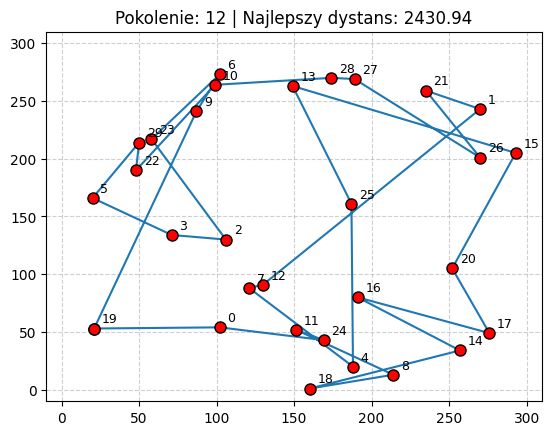

In [11]:
# Nowe parametry
n_pokolen = 200   # Zwiększenie liczby iteracji
p_mutacji = 0.5    # Wyższe prawdopodobieństwo dla inwersji
n_elita = 4        # Zachowanie 4 najlepszych osobników bez zmian
n_pop = liczebnosc_populacji
n_miasta = liczba_miast
coords_np = coords[['x', 'y']].values
historia_najlepszego_wyniku = []

for g in range(n_pokolen):
    # 1. Ocena jakości obecnej populacji[cite: 1]
    fun_jakosci(coords, populacja, n_pop, n_miasta)
    populacja = populacja.sort_values(by='Dystans').reset_index(drop=True)
    
    best_dist = populacja.iloc[0]['Dystans']
    historia_najlepszego_wyniku.append(best_dist)
    
    # Wizualizacja co 50 pokoleń
    #if g % 5 == 0:
    najlepsza_trasa = populacja.iloc[0, 0:n_miasta].values.astype(int)
    rysuj_trase_animacja(najlepsza_trasa, coords_np, g, best_dist)

    # 2. Inicjalizacja nowej populacji z uwzględnieniem elity[cite: 2]
    nowa_pop_list = []
    for i in range(n_elita):
        nowa_pop_list.append(populacja.iloc[i, 0:n_miasta].values.astype(int))
        
    # 3. Selekcja turniejowa rodziców[cite: 2]
    pula_rodzicow = selekcja_turniejowa(populacja, n_pop, wielkosc_turnieju=7)
    
    # 4. Krzyżowanie i nowa Mutacja[cite: 1, 2]
    for i in range(0, n_pop - n_elita, 2):
        r1 = pula_rodzicow.iloc[i, 0:n_miasta].values.astype(int)
        r2 = pula_rodzicow.iloc[i+1, 0:n_miasta].values.astype(int)
        
        # Krzyżowanie OX (Ordered Crossover)[cite: 1]
        d1, d2 = krzyzowanie_OX(r1, r2, n_miasta)
        
        # Zastosowanie inwersji zamiast swapu[cite: 2]
        d1 = mutacja_inversion(d1, p_mutacji)
        d2 = mutacja_inversion(d2, p_mutacji)
        
        nowa_pop_list.append(d1)
        nowa_pop_list.append(d2)

    # 5. Aktualizacja populacji[cite: 1]
    populacja = pd.DataFrame(nowa_pop_list[:n_pop], columns=range(n_miasta))

print(f"Ewolucja zakończona. Najlepszy dystans: {best_dist}")

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(historia_najlepszego_wyniku, color='red', linewidth=2)
plt.title('Postęp Algorytmu Genetycznego (TSP)')
plt.xlabel('Pokolenie')
plt.ylabel('Dystans (Najlepszy)')
plt.grid(True)
plt.show()